In [3]:
# ============================================================================
# SECTION 1: Setup and Dependencies
# ============================================================================

import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Core data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Statistics
from scipy import signal, stats

# Progress bars
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ All dependencies imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

✓ All dependencies imported successfully
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0


# MultiPhysio-HRC Dataset Exploration
## Sensor Fusion Research - Data Analysis

This notebook explores the MultiPhysio-HRC dataset for industrial human-robot collaboration research, examining multimodal physiological signals, facial features, and ground truth annotations for stress and cognitive load classification.

In [5]:
# ============================================================================
# SECTION 2: Dataset Access and Directory Setup
# ============================================================================

import subprocess
import tarfile
from urllib.error import HTTPError, URLError

# Detect environment (Colab vs Local)
try:
    from google.colab import drive
    IN_COLAB = True
    print("🔍 Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("🔍 Running locally")

# Setup paths
if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DATA_DIR = Path('/content/drive/MyDrive/MultiPhysio-HRC')  # Adjust path as needed
    OUTPUT_DIR = Path('/content/drive/MyDrive/research_outputs')
else:
    DATA_DIR = Path.home() / 'Desktop' / 'thesis' / 'data' / 'multiphysio_hrc'
    OUTPUT_DIR = Path.home() / 'Desktop' / 'thesis' / 'outputs' / 'exploration'

# Backward-compatible aliases used by later cells
data_dir = DATA_DIR
output_dir = OUTPUT_DIR

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DOWNLOAD_URL = 'https://zenodo.org/records/18668043/files/physiological_data.zip?download=1'
DOWNLOAD_FILE = DATA_DIR / 'physiological_data.zip'


def _download_file(url, destination_path):
    command = [
        'wget',
        '--show-progress',
        '--progress=bar:force:noscroll',
        '-O',
        str(destination_path),
        url,
    ]

    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end='')

    return_code = process.wait()
    if return_code != 0:
        raise RuntimeError(f"wget failed with exit code {return_code}")


def _extract_archive(archive_path, target_dir):
    suffixes = ''.join(archive_path.suffixes).lower()
    if suffixes.endswith('.zip'):
        import zipfile

        with zipfile.ZipFile(archive_path, 'r') as archive:
            archive.extractall(target_dir)
        return True
    if suffixes.endswith('.tar.gz') or suffixes.endswith('.tgz') or suffixes.endswith('.tar'):
        with tarfile.open(archive_path, 'r:*') as archive:
            archive.extractall(target_dir)
        return True
    return False


print(f"\n📁 Data directory: {DATA_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")
print('✓ Directories ready')

# Download automatically when the dataset directory is empty
existing_items = [item for item in DATA_DIR.iterdir() if item.name not in {'.DS_Store'}]
if not existing_items:
    try:
        if not DOWNLOAD_FILE.exists() or DOWNLOAD_FILE.stat().st_size == 0:
            print(f"\n⬇️  Downloading dataset with wget from: {DOWNLOAD_URL}")
            _download_file(DOWNLOAD_URL, DOWNLOAD_FILE)
        else:
            print(f"\n✓ Reusing existing download: {DOWNLOAD_FILE.name}")

        print("\n📦 Extracting dataset archive...")
        if _extract_archive(DOWNLOAD_FILE, DATA_DIR):
            print("✓ Archive extracted successfully")
        else:
            print("⚠️ Download completed, but the archive type was not recognized for extraction")
    except (HTTPError, URLError, RuntimeError, OSError) as error:
        print(f'\n⚠️ Automatic download failed: {error}')
        print('Manual download page: https://zenodo.org/records/18668043')
else:
    print(f'\n✓ Found {len(existing_items)} items in data directory')

# Refresh directory contents after download/extraction
existing_items = [item for item in DATA_DIR.iterdir() if item.name not in {'.DS_Store'}]
if existing_items:
    print(f"\n✓ Data directory now contains {len(existing_items)} items")

🔍 Running in Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Data directory: /content/drive/MyDrive/MultiPhysio-HRC
📁 Output directory: /content/drive/MyDrive/research_outputs
✓ Directories ready

⬇️  Downloading dataset with wget from: https://zenodo.org/records/18668043/files/physiological_data.zip?download=1
--2026-04-02 11:53:05--  https://zenodo.org/records/18668043/files/physiological_data.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.184.103.118, 188.185.48.75, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15329842648 (14G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/MultiPhysio-HRC/physiological_data.zip’


/content/drive/MyDr   0%[                    ]       0  --.-KB/s               
/content/drive/MyDr   0%[                    ]  44.91K   208KB/s     

In [10]:
# ============================================================================
# SECTION 3: Explore Dataset Structure
# ============================================================================

def resolve_dataset_root(base_dir):
    """Resolve dataset root that contains physiological_data/ and/or features/."""
    base_dir = Path(base_dir)

    if (base_dir / 'physiological_data').exists() or (base_dir / 'features').exists():
        return base_dir

    # If section 2 downloaded only the archive, try extraction here as a safeguard.
    zip_path = base_dir / 'physiological_data.zip'
    if zip_path.exists() and not (base_dir / 'physiological_data').exists():
        print('⚠️ Found archive but no extracted folders. Trying extraction...')
        if _extract_archive(zip_path, base_dir):
            print('✓ Extraction completed in Section 3')
            if (base_dir / 'physiological_data').exists() or (base_dir / 'features').exists():
                return base_dir

    # Sometimes data may be nested one level deeper.
    for child in base_dir.iterdir():
        if child.is_dir() and ((child / 'physiological_data').exists() or (child / 'features').exists()):
            return child

    return base_dir


def print_tree(root_dir, max_depth=3, prefix=''):
    """Simple tree printer for dataset exploration."""
    root_dir = Path(root_dir)
    if max_depth < 0 or not root_dir.exists():
        return

    items = sorted(root_dir.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for item in items:
        if item.is_dir():
            print(f"{prefix}📁 {item.name}/")
            print_tree(item, max_depth=max_depth - 1, prefix=prefix + '   ')
        else:
            size_mb = item.stat().st_size / (1024 * 1024)
            print(f"{prefix}📄 {item.name} ({size_mb:.2f} MB)")


DATASET_ROOT = resolve_dataset_root(DATA_DIR)
PHYSIO_ROOT = DATASET_ROOT / 'physiological_data'
FEATURES_ROOT = DATASET_ROOT / 'features'

print('📊 Resolved Dataset Paths')
print('=' * 60)
print(f'DATA_DIR      : {DATA_DIR}')
print(f'DATASET_ROOT  : {DATASET_ROOT}')
print(f'PHYSIO_ROOT   : {PHYSIO_ROOT} (exists: {PHYSIO_ROOT.exists()})')
print(f'FEATURES_ROOT : {FEATURES_ROOT} (exists: {FEATURES_ROOT.exists()})')

print('\n📂 Dataset Tree (depth=3):')
print('=' * 60)
print_tree(DATASET_ROOT, max_depth=3)

# Global inventory
all_files = [p for p in DATASET_ROOT.rglob('*') if p.is_file()]
all_dirs = [p for p in DATASET_ROOT.rglob('*') if p.is_dir()]
all_data_files = all_files

print('\n' + '=' * 60)
print('📈 Summary Statistics:')
print(f'  Total directories: {len(all_dirs)}')
print(f'  Total files: {len(all_data_files)}')
print(f"  Total data size: {sum(f.stat().st_size for f in all_data_files) / (1024**3):.2f} GB")

📊 Resolved Dataset Paths
DATA_DIR      : /content/drive/MyDrive/MultiPhysio-HRC
DATASET_ROOT  : /content/drive/MyDrive/MultiPhysio-HRC
PHYSIO_ROOT   : /content/drive/MyDrive/MultiPhysio-HRC/physiological_data (exists: True)
FEATURES_ROOT : /content/drive/MyDrive/MultiPhysio-HRC/features (exists: False)

📂 Dataset Tree (depth=3):
📁 physiological_data/
   📁 filtered/
      📁 10000/
         📄 cobot-task-1.csv (32.81 MB)
         📄 cobot-task-2.csv (52.40 MB)
         📄 cobot-task-3.csv (23.81 MB)
         📄 cobot-task-4.csv (27.48 MB)
         📄 cobot-task-5.csv (19.47 MB)
         📄 hanoi_0.csv (39.94 MB)
         📄 manual-task-1.csv (36.86 MB)
         📄 manual-task-2.csv (25.39 MB)
         📄 manual-task-3.csv (22.97 MB)
         📄 manual-task-4.csv (20.96 MB)
         📄 manual-task-5.csv (18.10 MB)
         📄 mat_0.csv (37.68 MB)
         📄 meditation_0.csv (10.01 MB)
         📄 n-back_0.csv (16.07 MB)
         📄 rest-1.csv (24.30 MB)
         📄 rest-2.csv (12.30 MB)
         📄 rest_

         📄 cobot-task-1.csv (31.67 MB)
         📄 cobot-task-2.csv (41.61 MB)
         📄 cobot-task-3.csv (31.53 MB)
         📄 cobot-task-4.csv (30.89 MB)
         📄 cobot-task-5.csv (22.80 MB)
         📄 hanoi_0.csv (13.42 MB)
         📄 manual-task-1.csv (23.07 MB)
         📄 manual-task-2.csv (14.40 MB)
         📄 manual-task-3.csv (36.50 MB)
         📄 manual-task-4.csv (15.21 MB)
         📄 manual-task-5.csv (16.02 MB)
         📄 mat_0.csv (12.54 MB)
         📄 meditation_0.csv (9.98 MB)
         📄 n-back_0.csv (13.15 MB)
         📄 rest-1.csv (24.24 MB)
         📄 rest-2.csv (12.24 MB)
         📄 rest_0.csv (9.84 MB)
         📄 stroopeasy_0.csv (11.41 MB)
         📄 stroophard_0.csv (7.99 MB)
         📄 vr-job-sim_0.csv (0.43 MB)
         📄 vr-plank_0.csv (12.31 MB)
      📁 1035/
         📄 cobot-task-1.csv (49.93 MB)
         📄 cobot-task-2.csv (34.32 MB)
         📄 cobot-task-3.csv (28.02 MB)
         📄 cobot-task-4.csv (32.53 MB)
         📄 cobot-task-5.csv (26.47 MB)
       

In [11]:
# ============================================================================
# SECTION 4: Identify Subject Data and File Formats
# ============================================================================

def collect_subject_directories(physio_root):
    """Collect subjects from raw/ and filtered/ folders."""
    physio_root = Path(physio_root)
    result = {'raw': {}, 'filtered': {}}

    for split in ['raw', 'filtered']:
        split_dir = physio_root / split
        if not split_dir.exists():
            continue

        for subj_dir in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
            csv_files = sorted(subj_dir.glob('*.csv'))
            result[split][subj_dir.name] = {
                'path': subj_dir,
                'num_csv': len(csv_files),
                'files': [f.name for f in csv_files],
            }

    return result


subject_dirs = collect_subject_directories(PHYSIO_ROOT)

# Unified subject dictionary used by later cells
all_subject_ids = sorted(set(subject_dirs.get('raw', {}).keys()) | set(subject_dirs.get('filtered', {}).keys()))
participants_info = {}
for sid in all_subject_ids:
    participants_info[sid] = {
        'raw': subject_dirs.get('raw', {}).get(sid),
        'filtered': subject_dirs.get('filtered', {}).get(sid),
    }

# File types across dataset
file_types = sorted({p.suffix.lower() for p in DATASET_ROOT.rglob('*') if p.is_file()})

print('👥 Subject Discovery')
print('=' * 60)
print(f'Total subjects discovered: {len(participants_info)}')
print(f'File types found: {file_types}')

num_raw = len(subject_dirs.get('raw', {}))
num_filtered = len(subject_dirs.get('filtered', {}))
print(f'Subjects with raw data: {num_raw}')
print(f'Subjects with filtered data: {num_filtered}')

if participants_info:
    print('\n📄 Sample subjects (first 5):')
    for sid in list(participants_info.keys())[:5]:
        raw_n = participants_info[sid]['raw']['num_csv'] if participants_info[sid]['raw'] else 0
        fil_n = participants_info[sid]['filtered']['num_csv'] if participants_info[sid]['filtered'] else 0
        print(f'  {sid}: raw={raw_n} csv, filtered={fil_n} csv')

# Optional feature-table quick check
if FEATURES_ROOT.exists():
    feature_csvs = sorted(FEATURES_ROOT.glob('*.csv'))
    print(f'\n🧩 Feature tables in features/: {len(feature_csvs)}')
    for fp in feature_csvs[:10]:
        print(f'  - {fp.name}')

👥 Subject Discovery
Total subjects discovered: 52
File types found: ['.csv', '.zip']
Subjects with raw data: 52
Subjects with filtered data: 52

📄 Sample subjects (first 5):
  10000: raw=21 csv, filtered=21 csv
  10001: raw=21 csv, filtered=21 csv
  1001: raw=21 csv, filtered=21 csv
  1002: raw=9 csv, filtered=9 csv
  1005: raw=21 csv, filtered=21 csv


In [12]:
# ============================================================================
# SECTION 5: Load Sample Data and Examine Format
# ============================================================================

def load_csv_data(file_path):
    """Load CSV data with automatic parsing."""
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print(f'  Error loading {file_path}: {e}')
        return None


def pick_sample_subject(participants_dict):
    """Pick a subject with filtered data first, otherwise raw."""
    for sid, info in participants_dict.items():
        if info.get('filtered') and info['filtered']['num_csv'] > 0:
            return sid, 'filtered'
    for sid, info in participants_dict.items():
        if info.get('raw') and info['raw']['num_csv'] > 0:
            return sid, 'raw'
    return None, None


sample_data = {}
sample_pid, sample_split = pick_sample_subject(participants_info)

if sample_pid is not None:
    print(f'🔬 Loading sample subject: {sample_pid} ({sample_split})')
    print('=' * 60)

    subj_info = participants_info[sample_pid][sample_split]
    subj_path = subj_info['path']
    task_files = sorted(subj_path.glob('*.csv'))

    if task_files:
        # Load first task file as physiological sample
        sample_task_file = task_files[0]
        physio_df = load_csv_data(sample_task_file)
        if physio_df is not None:
            sample_data['physiological'] = physio_df
            sample_data['physiological_file'] = str(sample_task_file)
            print(f'📊 Physiological sample file: {sample_task_file.name}')
            print(f'  Shape: {physio_df.shape}')
            print(f'  Columns (first 12): {list(physio_df.columns[:12])}')

        print(f'\n📁 Total task files for {sample_pid}: {len(task_files)}')
        print('  First 8 tasks:')
        for f in task_files[:8]:
            print(f'    - {f.name}')

# Load labels/features tables when available
if FEATURES_ROOT.exists():
    print('\n🧩 Loading feature/label tables from features/:')
    labels_path = FEATURES_ROOT / 'labels.csv'
    if labels_path.exists():
        labels_df = load_csv_data(labels_path)
        if labels_df is not None:
            sample_data['labels'] = labels_df
            print(f'  labels.csv shape: {labels_df.shape}')

    feature_tables = {}
    for feature_name in ['bio_features_60s.csv', 'eeg_features_5s.csv', 'speech_features.csv', 'aus_data.csv', 'nlp_embeddings.csv']:
        fp = FEATURES_ROOT / feature_name
        if fp.exists():
            df = load_csv_data(fp)
            if df is not None:
                feature_tables[feature_name] = df
                print(f'  {feature_name} shape: {df.shape}')

    sample_data['feature_tables'] = feature_tables

print('\n' + '=' * 60)
if sample_data:
    print('✓ Sample data loaded successfully')
else:
    print('⚠️ No sample data loaded. Check dataset extraction/path configuration.')

🔬 Loading sample subject: 10000 (filtered)
📊 Physiological sample file: cobot-task-1.csv
  Shape: (103768, 20)
  Columns (first 12): ['Unnamed: 0', 'ID', 'Class', 'Repetition', 'ECG', 'EDA', 'EMG', 'RESP', 'EEG_channel_0', 'EEG_channel_1', 'EEG_channel_2', 'EEG_channel_3']

📁 Total task files for 10000: 21
  First 8 tasks:
    - cobot-task-1.csv
    - cobot-task-2.csv
    - cobot-task-3.csv
    - cobot-task-4.csv
    - cobot-task-5.csv
    - hanoi_0.csv
    - manual-task-1.csv
    - manual-task-2.csv

✓ Sample data loaded successfully


In [13]:
# ============================================================================
# SECTION 6: Detailed Data Analysis
# ============================================================================

if sample_data and 'physiological' in sample_data:
    physio_df = sample_data['physiological']

    print('📊 Physiological Signals - Detailed Information')
    print('=' * 60)
    print(f"Source file: {sample_data.get('physiological_file', 'N/A')}")
    print(f'Shape: {physio_df.shape}')

    numeric_cols = physio_df.select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric columns: {len(numeric_cols)}')

    if numeric_cols:
        print('\n🔬 Numeric Signal Columns (first 20):')
        for col in numeric_cols[:20]:
            print(f'  - {col}')

        print('\n📈 Statistical Summary (numeric columns):')
        print('-' * 60)
        print(physio_df[numeric_cols].describe().to_string())

        missing_values = physio_df[numeric_cols].isnull().sum().sum()
        print(f'\n✓ Missing numeric values count: {missing_values}')
    else:
        print('⚠️ No numeric columns found in physiological sample file.')

if sample_data and 'labels' in sample_data:
    labels_df = sample_data['labels']

    print('\n\n📝 Ground Truth Labels - Detailed Information')
    print('=' * 60)
    print(f'Shape: {labels_df.shape}')
    print(f'Columns: {list(labels_df.columns)}')

    label_numeric_cols = labels_df.select_dtypes(include=[np.number]).columns.tolist()
    if label_numeric_cols:
        print('\n📋 Label Statistics (numeric columns):')
        print('-' * 60)
        print(labels_df[label_numeric_cols].describe().to_string())

if sample_data.get('feature_tables'):
    print('\n\n🧩 Feature Tables Loaded')
    print('=' * 60)
    for name, df in sample_data['feature_tables'].items():
        print(f'{name}: shape={df.shape}')

📊 Physiological Signals - Detailed Information
Source file: /content/drive/MyDrive/MultiPhysio-HRC/physiological_data/filtered/10000/cobot-task-1.csv
Shape: (103768, 20)
Numeric columns: 19

🔬 Numeric Signal Columns (first 20):
  - Unnamed: 0
  - ID
  - Repetition
  - ECG
  - EDA
  - EMG
  - RESP
  - EEG_channel_0
  - EEG_channel_1
  - EEG_channel_2
  - EEG_channel_3
  - EEG_channel_4
  - EEG_channel_5
  - EEG_channel_6
  - EEG_channel_7
  - EEG_channel_8
  - EEG_channel_9
  - EEG_channel_10
  - EEG_channel_11

📈 Statistical Summary (numeric columns):
------------------------------------------------------------
          Unnamed: 0        ID  Repetition            ECG           EDA           EMG           RESP  EEG_channel_0  EEG_channel_1  EEG_channel_2  EEG_channel_3  EEG_channel_4  EEG_channel_5  EEG_channel_6  EEG_channel_7  EEG_channel_8  EEG_channel_9  EEG_channel_10  EEG_channel_11
count  103768.000000  103768.0    103768.0  103768.000000  1.037680e+05  1.037680e+05  103768.0000

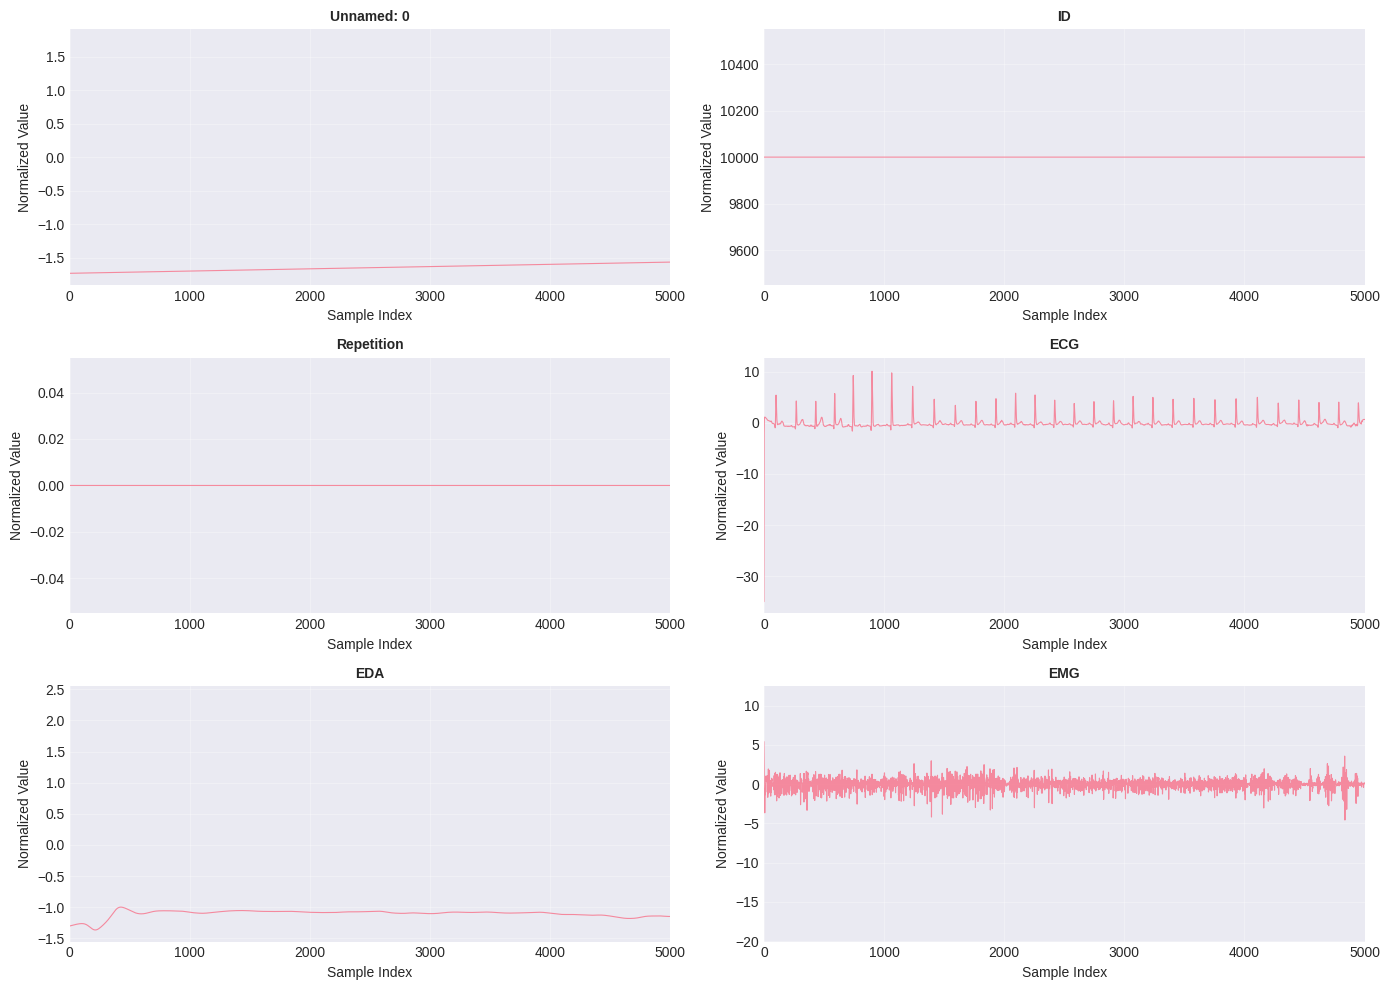

✓ Physiological signals visualization saved


In [14]:
# ============================================================================
# SECTION 7: Visualize Physiological Signals
# ============================================================================

if sample_data and 'physiological' in sample_data:
    physio_df = sample_data['physiological']
    numeric_cols = physio_df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) == 0:
        print('⚠️ No numeric columns available for plotting.')
    else:
        # Pick up to 6 representative numeric columns
        selected_cols = numeric_cols[:6]

        fig, axes = plt.subplots(3, 2, figsize=(14, 10))
        axes = axes.flatten()

        time_axis = np.arange(len(physio_df))

        for idx, col in enumerate(selected_cols):
            ax = axes[idx]
            values = physio_df[col].astype(float).values
            std = np.nanstd(values)
            if std > 0:
                values = (values - np.nanmean(values)) / std

            ax.plot(time_axis, values, linewidth=0.8, alpha=0.8)
            ax.set_title(col[:40], fontsize=10, fontweight='bold')
            ax.set_xlabel('Sample Index')
            ax.set_ylabel('Normalized Value')
            ax.grid(True, alpha=0.3)

            if len(time_axis) > 5000:
                ax.set_xlim([0, 5000])

        for idx in range(len(selected_cols), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'physiological_signals_sample.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('✓ Physiological signals visualization saved')

In [15]:
# ============================================================================
# SECTION 8: Visualize Ground Truth Labels Distribution
# ============================================================================

if sample_data and 'labels' in sample_data:
    labels_df = sample_data['labels']

    # Prefer known questionnaire names, fallback to numeric columns
    preferred = [
        col for col in labels_df.columns
        if any(x in col.lower() for x in ['stai', 'nasa', 'valence', 'arousal', 'dominance'])
    ]
    numeric_cols = labels_df.select_dtypes(include=[np.number]).columns.tolist()

    key_labels = preferred[:6] if preferred else numeric_cols[:6]

    if key_labels:
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        axes = axes.flatten()

        for idx, col in enumerate(key_labels):
            ax = axes[idx]
            data = labels_df[col].dropna()
            ax.hist(data, bins=20, alpha=0.7, color='steelblue', edgecolor='black')

            mean_val = data.mean()
            std_val = data.std()
            ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            if not np.isnan(std_val):
                ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
                ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='±1 Std')

            ax.set_title(col, fontweight='bold')
            ax.set_xlabel('Score')
            ax.set_ylabel('Frequency')
            ax.legend(fontsize=8)
            ax.grid(True, alpha=0.3)

        for idx in range(len(key_labels), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / 'labels_distribution.png', dpi=150, bbox_inches='tight')
        plt.show()

        print('✓ Labels distribution visualization saved')

        if len(key_labels) > 1:
            corr_matrix = labels_df[key_labels].corr(numeric_only=True)
            fig, ax = plt.subplots(figsize=(10, 8))
            sns.heatmap(
                corr_matrix,
                annot=True,
                fmt='.2f',
                cmap='coolwarm',
                center=0,
                square=True,
                ax=ax,
                cbar_kws={'label': 'Correlation'},
            )
            ax.set_title('Ground Truth Labels Correlation Matrix', fontweight='bold', fontsize=12)
            plt.tight_layout()
            plt.savefig(OUTPUT_DIR / 'labels_correlation.png', dpi=150, bbox_inches='tight')
            plt.show()

            print('✓ Correlation heatmap saved')
    else:
        print('⚠️ No suitable label columns found for visualization.')

In [16]:
# ============================================================================
# SECTION 9: Data Quality and Missing Values Analysis
# ============================================================================

print('🔍 Data Quality Assessment')
print('=' * 60)

if sample_data and 'physiological' in sample_data:
    physio_df = sample_data['physiological']
    numeric_df = physio_df.select_dtypes(include=[np.number])

    print('\n📊 Physiological Signals Quality:')
    print('-' * 60)

    if numeric_df.empty:
        print('⚠️ No numeric physiological columns for quality checks.')
    else:
        missing_pct = (numeric_df.isnull().sum() / len(numeric_df) * 100)
        missing_count = missing_pct[missing_pct > 0]

        if len(missing_count) > 0:
            print('\nColumns with missing values:')
            for col, pct in missing_count.items():
                print(f'  {col}: {pct:.1f}%')
        else:
            print('✓ No missing values in physiological numeric columns')

        print('\nOutlier detection (IQR method):')
        outlier_summary = []
        for col in numeric_df.columns:
            Q1 = numeric_df[col].quantile(0.25)
            Q3 = numeric_df[col].quantile(0.75)
            IQR = Q3 - Q1
            if pd.isna(IQR) or IQR == 0:
                continue
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            outliers = ((numeric_df[col] < lower_bound) | (numeric_df[col] > upper_bound)).sum()
            outlier_pct = outliers / len(numeric_df) * 100

            if outlier_pct > 1:
                outlier_summary.append((col, outlier_pct))

        if outlier_summary:
            for col, pct in sorted(outlier_summary, key=lambda x: x[1], reverse=True)[:10]:
                print(f'  {col}: {pct:.1f}% outliers')
        else:
            print('✓ No significant outliers detected')

if sample_data and 'labels' in sample_data:
    labels_df = sample_data['labels']
    label_numeric_df = labels_df.select_dtypes(include=[np.number])

    print('\n\n📝 Ground Truth Labels Quality:')
    print('-' * 60)

    if label_numeric_df.empty:
        print('⚠️ No numeric label columns found.')
    else:
        missing_pct = (label_numeric_df.isnull().sum() / len(label_numeric_df) * 100)
        missing_count = missing_pct[missing_pct > 0]

        if len(missing_count) > 0:
            print('\nColumns with missing values:')
            for col, pct in missing_count.head(10).items():
                print(f'  {col}: {pct:.1f}%')
        else:
            print('✓ No missing values in numeric label columns')

        print(f'\nTotal samples: {len(labels_df)}')
        print(f'Total features: {len(labels_df.columns)}')

🔍 Data Quality Assessment

📊 Physiological Signals Quality:
------------------------------------------------------------
✓ No missing values in physiological numeric columns

Outlier detection (IQR method):
  EEG_channel_3: 18.3% outliers
  EEG_channel_1: 16.9% outliers
  EEG_channel_4: 15.8% outliers
  EEG_channel_0: 14.1% outliers
  EEG_channel_9: 12.7% outliers
  EEG_channel_2: 12.2% outliers
  EMG: 11.1% outliers
  EEG_channel_8: 9.2% outliers
  EEG_channel_6: 8.9% outliers
  ECG: 8.6% outliers


In [17]:
# ============================================================================
# SECTION 10: Task Types and Experimental Conditions
# ============================================================================

print('\n📋 Experimental Protocol Overview (from Paper)')
print('=' * 60)

print('\nDAY 1 - Baseline and Stress Induction:')
print('-' * 60)
day1_tasks = {
    'Rest': 'Baseline measurement (2 min)',
    'Stroop Color Word Test': 'Cognitive stress - 3 min with varying speed',
    'N-Back Task': 'Working memory - 2 min',
    'Mental Arithmetic': 'Numerical challenge - 2 min',
    'Tower of Hanoi': 'Problem solving - no time limit',
    'Breathing Exercise': 'Relaxation - 2 min',
    'VR Game': "High-intensity experience (Richie's Plank)",
}
for task, description in day1_tasks.items():
    print(f'  • {task:30s}: {description}')

print('\nDAY 2 - Industrial HRC Tasks:')
print('-' * 60)
day2_tasks = {
    'Rest': 'Baseline measurement (5 min)',
    'Manual Disassembly': 'E-bike battery disassembly by hand',
    'Robot-Assisted Disassembly': 'Collaborative battery disassembly with Fanuc CRX-20',
}
for task, description in day2_tasks.items():
    print(f'  • {task:30s}: {description}')

print('\n\n🎯 Ground Truth Questionnaires Used:')
print('=' * 60)
questionnaires = {
    'STAI-Y1': '20 items, measures state anxiety/stress',
    'NASA-TLX': '6 items, measures workload (mental, physical, temporal, performance, effort, frustration)',
    'SAM': '3-dimensional (valence, arousal, dominance) on 1-5 scale',
    'NARS': 'Negative Attitudes Toward Robots (single administration)',
}
for name, description in questionnaires.items():
    print(f'  • {name:15s}: {description}')

print('\n\n🔬 Detected Dataset Schema Paths:')
print('=' * 60)
print(f'  • Physiological root: {PHYSIO_ROOT} (exists: {PHYSIO_ROOT.exists()})')
print(f'  • Features root     : {FEATURES_ROOT} (exists: {FEATURES_ROOT.exists()})')

if PHYSIO_ROOT.exists():
    for split in ['raw', 'filtered']:
        split_dir = PHYSIO_ROOT / split
        if split_dir.exists():
            n_subj = len([d for d in split_dir.iterdir() if d.is_dir()])
            print(f'  • {split:8s} subjects: {n_subj}')

if FEATURES_ROOT.exists():
    feature_files = sorted([p.name for p in FEATURES_ROOT.glob('*.csv')])
    print(f'  • features/*.csv files: {len(feature_files)}')
    for name in feature_files[:10]:
        print(f'      - {name}')


📋 Experimental Protocol Overview (from Paper)

DAY 1 - Baseline and Stress Induction:
------------------------------------------------------------
  • Rest                          : Baseline measurement (2 min)
  • Stroop Color Word Test        : Cognitive stress - 3 min with varying speed
  • N-Back Task                   : Working memory - 2 min
  • Mental Arithmetic             : Numerical challenge - 2 min
  • Tower of Hanoi                : Problem solving - no time limit
  • Breathing Exercise            : Relaxation - 2 min
  • VR Game                       : High-intensity experience (Richie's Plank)

DAY 2 - Industrial HRC Tasks:
------------------------------------------------------------
  • Rest                          : Baseline measurement (5 min)
  • Manual Disassembly            : E-bike battery disassembly by hand
  • Robot-Assisted Disassembly    : Collaborative battery disassembly with Fanuc CRX-20


🎯 Ground Truth Questionnaires Used:
  • STAI-Y1        : 20 item

In [18]:
# ============================================================================
# SECTION 11: Summary and Key Findings
# ============================================================================

print('\n\n📊 EXPLORATION SUMMARY')
print('=' * 80)

summary_items = []
summary_items.append(f'✓ Dataset root: {DATASET_ROOT}')
summary_items.append(f'✓ Subjects discovered: {len(participants_info)}')

raw_count = len([s for s, info in participants_info.items() if info.get('raw')])
filtered_count = len([s for s, info in participants_info.items() if info.get('filtered')])
summary_items.append(f'  └─ Raw subjects: {raw_count}, Filtered subjects: {filtered_count}')

if sample_data and 'physiological' in sample_data:
    physio_df = sample_data['physiological']
    summary_items.append(f"✓ Sample physiological file: {Path(sample_data.get('physiological_file', 'unknown')).name}")
    summary_items.append(f'  └─ Shape: {physio_df.shape}')

if sample_data and 'labels' in sample_data:
    labels_df = sample_data['labels']
    summary_items.append(f'✓ labels.csv loaded: {labels_df.shape}')

if sample_data.get('feature_tables'):
    summary_items.append(f"✓ Additional feature tables loaded: {len(sample_data['feature_tables'])}")

summary_items.append(f'✓ Output directory: {OUTPUT_DIR}')
summary_items.append('✓ Visualizations saved:')
summary_items.append('  └─ physiological_signals_sample.png')
summary_items.append('  └─ labels_distribution.png')
summary_items.append('  └─ labels_correlation.png')

for item in summary_items:
    print(item)

print('\n' + '=' * 80)
print('Next steps:')
print('  1. Verify full extraction completeness (archive integrity)')
print('  2. Process all subject task files into unified schema')
print('  3. Build baseline on features/labels.csv')
print('  4. Build temporal fusion from physiological_data/filtered/')
print('=' * 80)



📊 EXPLORATION SUMMARY
✓ Dataset root: /content/drive/MyDrive/MultiPhysio-HRC
✓ Subjects discovered: 52
  └─ Raw subjects: 52, Filtered subjects: 52
✓ Sample physiological file: cobot-task-1.csv
  └─ Shape: (103768, 20)
✓ Output directory: /content/drive/MyDrive/research_outputs
✓ Visualizations saved:
  └─ physiological_signals_sample.png
  └─ labels_distribution.png
  └─ labels_correlation.png

Next steps:
  1. Verify full extraction completeness (archive integrity)
  2. Process all subject task files into unified schema
  3. Build baseline on features/labels.csv
  4. Build temporal fusion from physiological_data/filtered/


In [19]:
# ============================================================================
# SECTION 12: Reusable Data Loading Functions
# ============================================================================

class MultiPhysioDataLoader:
    """Utility class for MultiPhysio-HRC schema-aware loading."""

    def __init__(self, dataset_root):
        self.dataset_root = Path(dataset_root)
        self.physio_root = self.dataset_root / 'physiological_data'
        self.features_root = self.dataset_root / 'features'
        self.subjects = self._find_subjects()

    def _find_subjects(self):
        subjects = set()
        for split in ['raw', 'filtered']:
            split_dir = self.physio_root / split
            if split_dir.exists():
                subjects |= {d.name for d in split_dir.iterdir() if d.is_dir()}
        return sorted(subjects)

    def list_subject_tasks(self, subject_id, split='filtered'):
        subj_dir = self.physio_root / split / str(subject_id)
        if not subj_dir.exists():
            return []
        return sorted(subj_dir.glob('*.csv'))

    def load_subject_task(self, subject_id, task_filename=None, split='filtered'):
        tasks = self.list_subject_tasks(subject_id, split=split)
        if not tasks:
            return None, None

        if task_filename is None:
            task_path = tasks[0]
        else:
            task_path = (self.physio_root / split / str(subject_id) / task_filename)
            if not task_path.exists():
                return None, None

        return task_path, pd.read_csv(task_path)

    def load_features_table(self, table_name='labels.csv'):
        table_path = self.features_root / table_name
        if not table_path.exists():
            return None
        return pd.read_csv(table_path)

    def get_subjects_summary(self):
        rows = []
        for sid in self.subjects:
            n_raw = len(self.list_subject_tasks(sid, split='raw'))
            n_filtered = len(self.list_subject_tasks(sid, split='filtered'))
            rows.append({
                'subject_id': sid,
                'n_raw_tasks': n_raw,
                'n_filtered_tasks': n_filtered,
            })
        return pd.DataFrame(rows)


# Initialize loader
if DATASET_ROOT.exists():
    print('\n🔧 Initializing Data Loader...')
    loader = MultiPhysioDataLoader(DATASET_ROOT)
    print(f'✓ Found {len(loader.subjects)} subjects')

    if loader.subjects:
        print(f'First subjects: {loader.subjects[:5]}')

    summary_df = loader.get_subjects_summary()
    if not summary_df.empty:
        print('\nSubjects summary (first 10 rows):')
        print(summary_df.head(10).to_string(index=False))

    # Save a compact summary CSV for reuse
    summary_path = OUTPUT_DIR / 'subjects_summary.csv'
    summary_df.to_csv(summary_path, index=False)
    print(f'\n✓ Saved subject summary: {summary_path}')


🔧 Initializing Data Loader...
✓ Found 52 subjects
First subjects: ['10000', '10001', '1001', '1002', '1005']

Subjects summary (first 10 rows):
subject_id  n_raw_tasks  n_filtered_tasks
     10000           21                21
     10001           21                21
      1001           21                21
      1002            9                 9
      1005           21                21
      1006            9                 9
      1007           21                21
      1008           21                21
      1009            9                 9
      1013            8                 8

✓ Saved subject summary: /content/drive/MyDrive/research_outputs/subjects_summary.csv


## Resources and References

### Dataset Resources
- **Official Dataset**: https://automation-robotics-machines.github.io/MultiPhysio-HRC.github.io/
- **Paper DOI**: https://doi.org/10.3390/robotics14120184
- **Bitbrain EEG Device**: https://www.bitbrain.com/neurotechnology-products/dry-eeg/diadem
- **Bitbrain Bio Sensors**: https://www.bitbrain.com/neurotechnology-products/biosignals/versatile-bio

### Key Paper Details
- **Publication Date**: December 5, 2025
- **Journal**: Robotics (MDPI)
- **Lead Author**: Andrea Bussolan (SUPSI)
- **Participants**: 55 (Day 1), 42 (Day 2)
- **Sampling Rate**: 256 Hz for physiological signals

### Modality Specifications
| Modality | Sensors | Channels | Sampling Rate |
|----------|---------|----------|---------------|
| EEG | Bitbrain Diadem | 12 dry | 256 Hz |
| ECG | Bitbrain Bio | 1 (V2 config) | 256 Hz |
| EDA | Bitbrain Bio | 1 (2-finger) | 256 Hz |
| EMG | Bitbrain Bio | 1 (trapezius) | 256 Hz |
| RESP | Bitbrain Bio | 1 (chest) | 256 Hz |
| Video | Webcam | RGB | 30 fps |
| Audio | Bluetooth mic | Mono | 48 kHz |

### Task Overview
**Day 1 (Stress Induction):**
- Stroop Color Word Test (3 min)
- N-Back (2 min)
- Mental Arithmetic (2 min)
- Tower of Hanoi (no time limit)
- Breathing Exercise (2 min)
- VR Game (Richie's Plank Experience)

**Day 2 (Industrial Tasks):**
- Manual e-bike battery disassembly
- Robot-assisted disassembly (Fanuc CRX-20 cobot)
- Repeated up to 5 times for fatigue induction

### Ground Truth Instruments
- **STAI-Y1**: 20-item state anxiety measure
- **NASA-TLX**: 6-dimensional workload assessment
- **SAM**: Valence, arousal, dominance (1-5 scale)
- **NARS**: Attitudes toward robots

### Feature Summary (from Paper)
- **Physiological**: 250 features (time/freq/complexity domain)
- **EEG**: 91 features (7 per channel × 12 + ratios)
- **Voice**: 30+ features (MFCC, prosody)
- **Facial**: 20 action units (Py-Feat XGBoost)
- **Text**: Embeddings from Whisper + Sentence Transformer

### Fusion Research Keywords
- Multimodal fusion
- Sensor fusion architecture
- Temporal-spatial modeling
- Attention mechanisms
- Task-conditional adaptation
- Human-robot collaboration
- Stress detection
- Cognitive load estimation

### Citation
```bibtex
@article{bussolan2025multiphysio,
  title={MultiPhysio-HRC: A Multimodal Physiological Signals Dataset for Industrial Human--Robot Collaboration},
  author={Bussolan, Andrea and Baraldo, Stefano and Avram, Oliver and Urcola, Pablo and Montesano, Luis and Gambardella, Luca Maria and Valente, Anna},
  journal={Robotics},
  volume={14},
  number={12},
  pages={184},
  year={2025},
  doi={10.3390/robotics14120184}
}
```

In [20]:
# SECTION 13: Compact Analysis Report (Auto-generated)

from pathlib import Path
import pandas as pd
import numpy as np

report = {}

report['dataset_root'] = str(DATASET_ROOT) if 'DATASET_ROOT' in globals() else 'N/A'
report['physio_root_exists'] = bool(PHYSIO_ROOT.exists()) if 'PHYSIO_ROOT' in globals() else False
report['features_root_exists'] = bool(FEATURES_ROOT.exists()) if 'FEATURES_ROOT' in globals() else False

if 'participants_info' in globals() and isinstance(participants_info, dict):
    report['n_subjects'] = len(participants_info)
    report['n_subjects_raw'] = sum(1 for _, info in participants_info.items() if info.get('raw'))
    report['n_subjects_filtered'] = sum(1 for _, info in participants_info.items() if info.get('filtered'))
else:
    report['n_subjects'] = 0
    report['n_subjects_raw'] = 0
    report['n_subjects_filtered'] = 0

if 'sample_data' in globals() and isinstance(sample_data, dict) and 'physiological' in sample_data:
    p = sample_data['physiological']
    num = p.select_dtypes(include=[np.number])
    report['sample_physio_shape'] = tuple(p.shape)
    report['sample_physio_numeric_cols'] = len(num.columns)
    report['sample_physio_missing_values'] = int(num.isnull().sum().sum()) if len(num.columns) else 0
else:
    report['sample_physio_shape'] = None
    report['sample_physio_numeric_cols'] = 0
    report['sample_physio_missing_values'] = None

if 'sample_data' in globals() and isinstance(sample_data, dict) and 'labels' in sample_data:
    l = sample_data['labels']
    lnum = l.select_dtypes(include=[np.number])
    report['labels_shape'] = tuple(l.shape)
    report['labels_numeric_cols'] = len(lnum.columns)
    report['labels_missing_values'] = int(lnum.isnull().sum().sum()) if len(lnum.columns) else 0
else:
    report['labels_shape'] = None
    report['labels_numeric_cols'] = 0
    report['labels_missing_values'] = None

if 'sample_data' in globals() and isinstance(sample_data, dict) and sample_data.get('feature_tables'):
    report['feature_tables'] = {k: tuple(v.shape) for k, v in sample_data['feature_tables'].items()}
else:
    report['feature_tables'] = {}

if 'summary_df' in globals() and isinstance(summary_df, pd.DataFrame) and not summary_df.empty:
    report['subject_task_stats'] = {
        'n_rows': int(len(summary_df)),
        'avg_raw_tasks': float(summary_df['n_raw_tasks'].mean()) if 'n_raw_tasks' in summary_df else None,
        'avg_filtered_tasks': float(summary_df['n_filtered_tasks'].mean()) if 'n_filtered_tasks' in summary_df else None,
        'max_raw_tasks': int(summary_df['n_raw_tasks'].max()) if 'n_raw_tasks' in summary_df else None,
        'max_filtered_tasks': int(summary_df['n_filtered_tasks'].max()) if 'n_filtered_tasks' in summary_df else None,
    }
else:
    report['subject_task_stats'] = {}

print('=== COMPACT DATASET ANALYSIS REPORT ===')
for k, v in report.items():
    print(f'{k}: {v}')

=== COMPACT DATASET ANALYSIS REPORT ===
dataset_root: /content/drive/MyDrive/MultiPhysio-HRC
physio_root_exists: True
features_root_exists: False
n_subjects: 52
n_subjects_raw: 52
n_subjects_filtered: 52
sample_physio_shape: (103768, 20)
sample_physio_numeric_cols: 19
sample_physio_missing_values: 0
labels_shape: None
labels_numeric_cols: 0
labels_missing_values: None
feature_tables: {}
subject_task_stats: {'n_rows': 52, 'avg_raw_tasks': 17.673076923076923, 'avg_filtered_tasks': 17.673076923076923, 'max_raw_tasks': 21, 'max_filtered_tasks': 21}


In [21]:
# SECTION 14: Deep Structural Analysis

from collections import Counter, defaultdict

analysis = {
    'task_frequency_filtered': {},
    'task_frequency_raw': {},
    'common_numeric_columns_sample': [],
    'subject_task_count_distribution_filtered': {},
    'subject_task_count_distribution_raw': {},
}

# Collect task frequencies
if 'loader' in globals() and hasattr(loader, 'subjects'):
    filtered_counter = Counter()
    raw_counter = Counter()
    filtered_counts = []
    raw_counts = []

    for sid in loader.subjects:
        f_tasks = loader.list_subject_tasks(sid, split='filtered')
        r_tasks = loader.list_subject_tasks(sid, split='raw')
        filtered_counts.append(len(f_tasks))
        raw_counts.append(len(r_tasks))

        for t in f_tasks:
            filtered_counter[t.name] += 1
        for t in r_tasks:
            raw_counter[t.name] += 1

    analysis['task_frequency_filtered'] = dict(filtered_counter.most_common(15))
    analysis['task_frequency_raw'] = dict(raw_counter.most_common(15))
    analysis['subject_task_count_distribution_filtered'] = dict(sorted(Counter(filtered_counts).items()))
    analysis['subject_task_count_distribution_raw'] = dict(sorted(Counter(raw_counts).items()))

# Numeric column overview from first 5 subjects
if 'loader' in globals() and hasattr(loader, 'subjects'):
    col_counter = Counter()
    inspected = 0
    for sid in loader.subjects:
        task_path, df = loader.load_subject_task(sid, split='filtered')
        if df is None:
            continue
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        col_counter.update(numeric_cols)
        inspected += 1
        if inspected >= 5:
            break

    analysis['common_numeric_columns_sample'] = col_counter.most_common(25)

print('=== DEEP STRUCTURAL ANALYSIS ===')
print(f"Top filtered task filenames: {analysis['task_frequency_filtered']}")
print(f"Top raw task filenames: {analysis['task_frequency_raw']}")
print(f"Filtered per-subject task count distribution: {analysis['subject_task_count_distribution_filtered']}")
print(f"Raw per-subject task count distribution: {analysis['subject_task_count_distribution_raw']}")
print('Most common numeric columns across sampled subjects (name, count):')
print(analysis['common_numeric_columns_sample'])

=== DEEP STRUCTURAL ANALYSIS ===
Top filtered task filenames: {'hanoi_0.csv': 51, 'n-back_0.csv': 51, 'rest_0.csv': 51, 'stroopeasy_0.csv': 51, 'stroophard_0.csv': 51, 'mat_0.csv': 50, 'meditation_0.csv': 50, 'vr-plank_0.csv': 49, 'manual-task-2.csv': 42, 'manual-task-3.csv': 42, 'manual-task-4.csv': 42, 'rest-1.csv': 42, 'rest-2.csv': 42, 'cobot-task-1.csv': 41, 'manual-task-1.csv': 41}
Top raw task filenames: {'hanoi_0.csv': 51, 'n-back_0.csv': 51, 'rest_0.csv': 51, 'stroopeasy_0.csv': 51, 'stroophard_0.csv': 51, 'mat_0.csv': 50, 'meditation_0.csv': 50, 'vr-plank_0.csv': 49, 'manual-task-2.csv': 42, 'manual-task-3.csv': 42, 'manual-task-4.csv': 42, 'rest-1.csv': 42, 'rest-2.csv': 42, 'cobot-task-1.csv': 41, 'manual-task-1.csv': 41}
Filtered per-subject task count distribution: {8: 4, 9: 6, 12: 2, 15: 1, 17: 1, 18: 1, 19: 3, 20: 12, 21: 22}
Raw per-subject task count distribution: {8: 4, 9: 6, 12: 2, 15: 1, 17: 1, 18: 1, 19: 3, 20: 12, 21: 22}
Most common numeric columns across sample

In [22]:
# SECTION 15: Signal Length and Modality Consistency Checks

length_stats = []
column_sets = []

if 'loader' in globals() and hasattr(loader, 'subjects'):
    for sid in loader.subjects:
        tasks = loader.list_subject_tasks(sid, split='filtered')
        if not tasks:
            continue

        # Sample first filtered task per subject for quick consistency audit
        task_path, df = loader.load_subject_task(sid, split='filtered')
        if df is None:
            continue

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        length_stats.append({
            'subject_id': sid,
            'task_file': task_path.name,
            'n_rows': int(df.shape[0]),
            'n_cols': int(df.shape[1]),
            'n_numeric_cols': int(len(numeric_cols)),
        })
        column_sets.append(tuple(df.columns.tolist()))

length_df = pd.DataFrame(length_stats)

print('=== SIGNAL LENGTH / CONSISTENCY CHECK ===')
if not length_df.empty:
    print('Sampled first filtered task per subject')
    print(f"Subjects sampled: {len(length_df)}")
    print(f"Row count stats: min={length_df['n_rows'].min()}, mean={length_df['n_rows'].mean():.1f}, median={length_df['n_rows'].median():.1f}, max={length_df['n_rows'].max()}")
    print(f"Column count stats: min={length_df['n_cols'].min()}, mean={length_df['n_cols'].mean():.1f}, max={length_df['n_cols'].max()}")
    print(f"Numeric column stats: min={length_df['n_numeric_cols'].min()}, mean={length_df['n_numeric_cols'].mean():.1f}, max={length_df['n_numeric_cols'].max()}")

    unique_col_layouts = len(set(column_sets))
    print(f"Unique column layouts among sampled tasks: {unique_col_layouts}")

    print('\nTop 10 sampled tasks by row count:')
    print(length_df.sort_values('n_rows', ascending=False).head(10).to_string(index=False))
else:
    print('No subject-level consistency data available.')

=== SIGNAL LENGTH / CONSISTENCY CHECK ===
Sampled first filtered task per subject
Subjects sampled: 52
Row count stats: min=592, mean=99759.9, median=102110.0, max=227357
Column count stats: min=20, mean=20.0, max=20
Numeric column stats: min=19, mean=19.0, max=19
Unique column layouts among sampled tasks: 1

Top 10 sampled tasks by row count:
subject_id        task_file  n_rows  n_cols  n_numeric_cols
      1032 cobot-task-1.csv  227357      20              19
      1051 cobot-task-1.csv  219823      20              19
      1038 cobot-task-1.csv  170980      20              19
      1035 cobot-task-1.csv  158078      20              19
      1036 cobot-task-1.csv  156322      20              19
      1090 cobot-task-1.csv  151027      20              19
      1041 cobot-task-1.csv  147100      20              19
      1057 cobot-task-1.csv  145224      20              19
      1065 cobot-task-1.csv  134874      20              19
      1075 cobot-task-1.csv  132920      20           